# Goal for this notebook 
Create a circulized plot of my genome :
1. 349 bp repeat regions --> bed file
3. Tandem repeat (trf) --> bed file 
4. Interspersed repeat (repeatMasker) --> Bed file
5. Coverage file 
6. Segmental duplication (biser)

In [14]:
import pandas as pd
from pycirclize import Circos
from pycirclize.parser import Genbank
from pycirclize.utils import load_prokaryote_example_file,  ColorCycler
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from pycirclize.parser import Gff
ColorCycler.set_cmap("Set3")
from Bio.SeqFeature import SeqFeature, FeatureLocation
from pycirclize.utils import load_eukaryote_example_dataset
from pycirclize import Circos
from matplotlib.colors import to_rgba
from matplotlib.colors import to_hex, to_rgba
import seaborn as sns
import pyranges as pr

In [15]:

fai = pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/041425-assembly/hifiasm-041425-assembly-mitoFiltered-scaffolded-curated-masked-chrNameAssigned/assembly_final.sorted.headerRenamed.chrAssigned.hardMasked.mito.fasta.fai",
    sep="\t",
    header=None,
    names=["chr", "length", "offset", "linebases", "linewidth"]
)

# 2. Filter for chromosomes and keep first 4
karyotype = fai[fai["chr"].str.contains("chr")].head(4)[["chr", "length"]]

# 3. Set gap degrees (5° after last chromosome)
gap_degrees = 5
gap_after = [1] * (len(karyotype) - 1) + [gap_degrees]

chr_sizes = dict(zip(karyotype['chr'], karyotype['length']))
circos = Circos(sectors=chr_sizes, start=10, end=350, space=2, endspace=False)


########################### Segdup density level gene level #########################
sd_gene_density=pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/segdup-investigation/segdup_density_rolling_5000000_100000_geneLevel.tsv",sep="\t")

########################### Segdup density level gene level #########################
sd_bp_density=pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/segdup-investigation/segdup_density_rolling_5000000_100000_bpLevel.tsv",sep="\t")

########################### Segmental duplication  ##########################
# Read BEDPE file
bedpe = pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/genome-annotation/biser/hifiasm-041425/segdup_output_mod.bedpe",
    sep="\t",
    header=None,
    names=["chr1", "start1", "end1", "chr2", "start2", "end2"]
)

bedpe = bedpe.sample(frac=0.1, random_state=28)  # random 1000 rows


########################### Add in contig junction information ##########################
# Assuming your junction BED file has columns: chr, start, end, name
junction_bed = pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/circos-plot/feature-overview/agp_final_contig2scaffold.bed",
    sep="\t",
    header=0,
    dtype={
        "chr": "string",    # Explicit string type
        "start": "int64",   # 64-bit integer
        "end": "int64"},     # 64-bit integer
    names=["chr", "start", "end"],
    na_values=["."],        # Common NA marker in BED files
    keep_default_na=False   # Prevent unwanted NA conversion
)

chr_colors = {
    'chr1': '#FF6B6B', 'chr2': '#4ECDC4', 'chr3': '#45B7D1', 'chr4': '#FFA07A',
    'chr5': '#92D050', 'chr6': '#D35FB7', 'chr7': '#FFC000', 'chr8': '#00B0F0',
    'chr9': '#A2D96C', 'chr10': '#C00000', 'chr11': '#7030A0', 'chr12': '#FF5733',
    'chr13': '#00AEEF', 'chr14': '#FF99CC', 'chr15': '#8FD8D8', 'chr16': '#F6546A',
    'chr17': '#468499', 'chr18': '#FFD700', 'chr19': '#088DA5', 'chr20': '#F08080',
    'chr21': '#6A5ACD', 'chr22': '#65B891', 'chr23': '#FFA500', 'chr24': '#BA55D3',
    'chr25': '#9370DB', 'chr26': '#3CB371', 'chr27': '#7B68EE', 'chr28': '#40E0D0',
    'chrX': '#FF1493',  # Distinct pink for X
    'chrY': '#14FF82'   # Dark blue for Y
}

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
chr21
chr22
chr23
chr24
chr25
chr26
chr27
chr28
chrX
chrY
CPU times: user 15.1 s, sys: 446 ms, total: 15.5 s
Wall time: 15.6 s


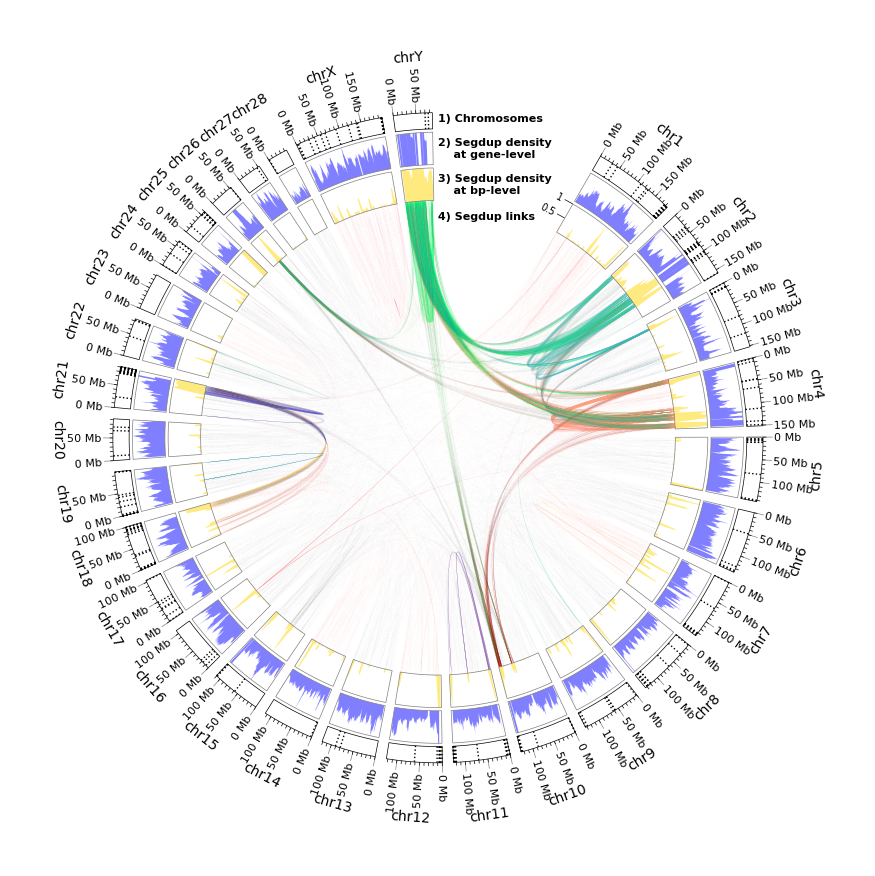

In [16]:
%%time

y_max=1

# 2. Filter for chromosomes and keep first 4
karyotype = fai[fai["chr"].str.contains("chr")][["chr", "length"]]

# # 3. Set gap degrees (5° after last chromosome)
# gap_degrees = 5
# gap_after = [1] * (len(karyotype) - 1) + [gap_degrees]

chr_sizes = dict(zip(karyotype['chr'], karyotype['length']))
circos = Circos(sectors=chr_sizes, start=30, end=359, space=2, endspace=False)
# circos.text("Octodon degus \n assembly", size=12, r=0)


############ ====> PLOT
# 4. Plot GC track
for i, sector in enumerate(circos.sectors):
    print(sector.name)

    ######## Junction track 
    # Add a new track for junction points
    junction_track = sector.add_track((95, 100))  # Just inside your axis track
    # Plot junction points for this chromosome
    chr_junctions = junction_bed[junction_bed["chr"] == sector.name]
    for _, row in chr_junctions.iterrows():
        # Calculate position in degrees
        posS = row["start"]  # or use midpoint: (row["start"] + row["end"]) / 2
        posE = row["end"]  # or use midpoint: (row["start"] + row["end"]) / 2
        
        # Create a line plot instead of scatter to show junctions
        junction_track.line(
            x=[posS, posE],  # Same x position for start and end
            y=[0,100],    # Vertical line from inner to outer radius
            color="black",
            lw=1,
            arc=True,
            ls=":")
        
    ### PLOT Segmental duplication #######
    #### Density track for genes in segdup regions
    sub_density = sd_gene_density[sd_gene_density["Chromosome"] == sector.name]
    if sub_density.empty:  # Skip if no data
        print(f"No density data for {sector.name}")
        continue
    density_track = sector.add_track((94, 84))
    density_track.axis(fc="none", ec="grey", lw=0.5)
    x = (sub_density["Start"] + sub_density["End"]) / 2
    y = sub_density["percent_dup"].values
    # Clip x-values to sector range to avoid errors
    x_clipped = np.clip(x, sector.start, sector.end)
    # Normalize y if needed
    y_norm = (y - y.min()) / (y.max() - y.min()) if y.max() > 0 else y
    density_track.fill_between(
        x_clipped, y_norm, 0,vmax=1,  # Use clipped x-values
        color="blue", alpha=0.5, ec="none"
    )

    ### Density track for bp level in segdup regions
    sub_density = sd_bp_density[sd_bp_density["Chromosome"] == sector.name]
    if sub_density.empty:  # Skip if no data
        print(f"No density data for {sector.name}")
        continue
    density_track = sector.add_track((83, 73))
    density_track.axis(fc="none", ec="grey", lw=0.5)
    x = (sub_density["Start"] + sub_density["End"]) / 2
    y = sub_density["percent_segdup"].values
    # Clip x-values to sector range to avoid errors
    x_clipped = np.clip(x, sector.start, sector.end)
    # Normalize y if needed
    y_norm = (y - y.min()) / (y.max() - y.min()) if y.max() > 0 else y
    density_track.fill_between(
        x_clipped, y_norm, 0,vmax=1,  # Use clipped x-values
        color="gold", alpha=0.5, ec="none"
    )


    # (optional) also draw your major/minor ticks as before
    outer = sector.add_track((95, 100))
    outer.axis(fc="none", ec="black", lw=0.5)
    interval = 50_000_000  # 50 Mb
    outer.xticks_by_interval(
        interval=interval,
        tick_length=3,
        outer=True,
        show_label=True,
        label_size=8,
        label_orientation="vertical",
        label_formatter=lambda v: f"{v/1e6:.0f} Mb",
        line_kws=dict(ec="grey")
    )

    
    # **Minor ticks every 10 Mb without labels**
    outer.xticks_by_interval(
        interval=10_000_000,     # 10 Mb interval :contentReference[oaicite:1]{index=1}
        tick_length=1,           # shorter tick length :contentReference[oaicite:2]{index=2}
        outer=True,
        show_label=False,        # no labels on minor ticks :contentReference[oaicite:3]{index=3}
        line_kws=dict(ec="black", lw=0.5)
    )

    # chromosome label
    mid = (sector.start + sector.end) / 2
    sector.text(text=sector.name, x=mid, r=115,
                adjust_rotation=True, size=10)

    
    if i == 0:  # First sector only
        density_track.yticks(
            y=[0.5, 1.0],           # Y-values where ticks should appear
            labels=["0.5", "1"], # Labels for these ticks
            side="left",                # Place ticks on the left side
            tick_length=2,              # Length of the tick lines
            label_size=7,              # Font size for labels
        )

# Filter for valid chromosomes
valid_chrs = list(chr_sizes.keys())
bedpe_filtered = bedpe[
    (bedpe["chr1"].isin(valid_chrs)) & 
    (bedpe["chr2"].isin(valid_chrs))
]
# Define the radial positions for your links
# r1 =72  # Inner radius for link starts
# r2 = 72  # Outer radius for link ends

# Plot links
for _, row in bedpe_filtered.iterrows():
    region1 = (row['chr1'], row['start1'], row['end1'])
    region2 = (row['chr2'], row['start2'], row['end2'])
    # Use color based on source chromosome with transparency
    color = to_rgba(chr_colors[row['chr1']], alpha=0.3)
    # Different linewidths for intra vs inter-chromosomal
    lw = 0.8 if row['chr1'] == row['chr2'] else 0.5
    circos.link(
        region1, 
        region2, 
        # r1=r1,  # Set inner radius
        # r2=r2,  # Set outer radius
        color=color, 
        direction=1, 
        ec="none", 
        lw=lw
    )

# 5. Render
# circos.plotfig()
# _=circos.plotfig()
fig = circos.plotfig()
ax = fig.axes[0]  # Get the polar axes

# Define label positions (track_top, text, color)
track_labels = [
    (95, "1) Chromosomes", "black"),
    (84, "2) Segdup density\n    at gene-level","black"),
    (73, "3) Segdup density\n    at bp-level","black"),
    (65, "4) Segdup links", "black")
]

# Add each label in the gap space (0° angle)
for track_top, text, color in track_labels:
    ax.text(
        np.deg2rad(-0),       # 0° angle (center of gap)
        track_top + 1.5,     # Place text just above track
        text,
        rotation=0,          # Keep horizontal
        ha='left',
        va='bottom',
        color=color,
        size=8,
        fontweight='bold'
    )

fig.tight_layout()
fig.show()

In [17]:
# Save in PNG (lossless) or PDF/SVG (vector)
fig.savefig(
    "degus_genome_circos_segdup_overview.png",  # For PNG
    dpi=600,               # Ultra-high resolution (300-600 for print)
    bbox_inches="tight",   # Prevents cropping
    transparent=False,     # Set to True if you need transparency
    facecolor="white"      # Background color
)

In [ ]:
# Save in PNG (lossless) or PDF/SVG (vector)
fig.savefig(
    "degus_genome_circos_segdup_overview.pdf",  # For PNG
    dpi=600,               # Ultra-high resolution (300-600 for print)
    bbox_inches="tight",   # Prevents cropping
    transparent=False,     # Set to True if you need transparency
    facecolor="white"      # Background color
)

In [ ]:
# Save in PNG (lossless) or PDF/SVG (vector)
fig.savefig(
    "degus_genome_circos_segdup_overview.svg",  
    dpi=600,               # Ultra-high resolution (300-600 for print)
    bbox_inches="tight",   # Prevents cropping
    transparent=False,     # Set to True if you need transparency
    facecolor="white"      # Background color
)